In [1]:
# import packages
import pandas as pd
import numpy as np
from typing import Union

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import pymc as pm
import pymc.sampling.jax as pmjax
import pytensor.tensor as pt
import arviz as az
import arviz_plots as azp
import xarray as xr

import matplotlib.pyplot as plt
RANDOM_SEED = 457775 # https://www.reddit.com/r/baseball/comments/b5vfik/whos_the_most_random_mlb_player_you_can_think_of/
np.random.seed(RANDOM_SEED)

# for reproducibility
print("pandas: "+pd.__version__)
print("numpy: "+np.__version__)
print("pymc: "+pm.__version__)
import sklearn
print("sklearn: "+sklearn.__version__)
import pytensor
print("pytensor: "+pytensor.__version__)
print("arviz: "+az.__version__)
print("arviz_plots: "+azp.__version__)

pandas: 3.0.1
numpy: 2.4.3
pymc: 5.28.2
sklearn: 1.8.0
pytensor: 2.38.2
arviz: 0.23.4
arviz_plots: 1.0.0


In [2]:
# import data
df = pd.read_csv('data/bat_speed_model_data.csv')
df['bam_id'] = pd.to_numeric(df['bam_id'], errors='coerce')
df.head()

,bam_id,year,month_name,time_index,player_full_id,full,first,last,bats,birth_date,...,bips,ev90,latent_ev90,latent_ev90_std,swings,bat_speed,imputed_bat_speed,imputed_bat_speed_std,model_bat_speed,model_bat_speed_std
0,405395,2021,Mar/Apr,0,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,63.0,106.16,106.177,0.564,NaN,NaN,72.319750,1.638141,72.319750,1.638141
1,405395,2021,May,1,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,41.0,108.40,107.838,0.686,NaN,NaN,73.605947,1.653297,73.605947,1.653297
2,405395,2021,Jun,2,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,41.0,103.90,104.412,0.686,NaN,NaN,70.952174,1.654974,70.952174,1.654974
3,405395,2021,Jul,3,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,44.0,105.79,105.652,0.666,NaN,NaN,71.908811,1.658140,71.908811,1.658140
4,405395,2021,Aug,4,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,19.0,105.56,105.493,0.937,NaN,NaN,71.774109,1.728959,71.774109,1.728959


In [ ]:
# df['country_recode'] = np.where(df['country2'].isin(['East North Central, USA', 'East South Central, USA', 'West South Central, USA', 'West North Central, USA']), 'Central, USA', df['country2'])
# df['country_recode'] = np.where(df['country_recode'].isin(['Pacific North West, USA', 'Mountain, USA']), 'West, USA', df['country_recode'])
# df['country_recode'] = np.where(df['country_recode'].isin(['New England, USA', 'South Mid-Atlantic, USA', 'Virginias, USA', 'Mid-Atlantic, USA', 'South Atlantic, USA', ]), 'East, USA', df['country_recode'])
# df['country_recode'] = np.where(df['country_recode'].isin(['Europe', 'Canada', 'Puerto Rico', 'Pacific']), 'Other', df['country_recode'])
# df['country_recode'].value_counts()

# df['split_column'] = df['position'] + '_' + df['country_recode']

# # rip off 2026 to help forecast
# forecast_df = df.loc[df['year'] == 2026].reset_index(drop=True)
# df = df.loc[df['year'] < 2026].reset_index(drop=True)

# # define the train and test sets, split by bam_id, stratified by position and country
# player_df = df[['bam_id', 'position', 'country_recode']].drop_duplicates().reset_index(drop=True)
# player_df['split_column'] = player_df['position'] + '_' + player_df['country_recode']
# # remove players with unique split_column values, only 1 player in that position and country
# players_removed = player_df['split_column'].value_counts()[player_df['split_column'].value_counts() == 1].index.tolist()
# players_add_back = player_df[player_df['split_column'].isin(players_removed)]
# player_df = player_df[~player_df['split_column'].isin(players_removed)]

# # split
# train_players, test_players = train_test_split(player_df, test_size=0.25, random_state=RANDOM_SEED, stratify=player_df['split_column'])

# # create the train and test sets
# train_players = pd.concat([train_players, players_add_back], ignore_index=True)
# train_df = df[df['bam_id'].isin(train_players['bam_id'])].reset_index(drop=True)
# test_df = df[df['bam_id'].isin(test_players['bam_id'])].reset_index(drop=True)

# print(train_df.shape)
# print(test_df.shape)
# print(len(players_removed))

# # who got removed from the split?
# print(df.loc[df['split_column'].isin(players_removed)]['full'].value_counts())

# # scale age
# train_age = train_df['age'].mean()
# train_age_std = train_df['age'].std()
# train_df['age_z'] =  (train_df['age'] - train_age) / train_age_std
# test_df['age_z'] =  (test_df['age'] - train_age) / train_age_std

# # scale bat_speed
# train_bat_speed_mean = train_df['model_bat_speed'].mean()
# train_bat_speed_std = train_df['model_bat_speed'].std()

# train_df['model_bat_speed_z'] = (train_df['model_bat_speed'] - train_bat_speed_mean) / train_bat_speed_std
# test_df['model_bat_speed_z'] = (test_df['model_bat_speed'] - train_bat_speed_mean) / train_bat_speed_std

# train_df['model_bat_speed_std_z'] = train_df['model_bat_speed_std'] / train_bat_speed_std
# test_df['model_bat_speed_std_z'] = test_df['model_bat_speed_std'] / train_bat_speed_std

# train_df.tail()

# # init values
# train_age = train_df['age_z'].values
# train_age_sq = train_age**2
# train_bat_speed_z = train_df['model_bat_speed_z'].values
# train_bat_speed_std_z = train_df['model_bat_speed_std_z'].values

country_recode
Central, USA          2814
East, USA             2650
California, USA       2500
Dominican Republic    1551
Venezuela             1474
Latin America         1136
Florida, USA          1104
West, USA             1004
Other                  970
Name: count, dtype: int64

In [3]:
# These are some generic helper functions to help sample for the model
def sample(model: pm.Model, draws: int = 2000, tune: int = 2000, chains: int = 4, target_accept: float = 0.99, random_seed: int = RANDOM_SEED, path:str = 'temp.nc', **kwargs):
    """
    Fit model using MCMC.

    Parameters
    ----------
    model: pm.Model
        PyMC model object.
    draws : int
        Number of draws to keep from the sampling process.
    tune : int
        Number of tuning steps to take before sampling.
    chains : int
        Number of chains to sample.
    target_accept : float
        Target acceptance probability for step size adaptation.
    random_seed : int
        Seed for randomness.
    """
    with model:
        trace = pmjax.sample_numpyro_nuts(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            idata_kwargs={"log_likelihood": False}
        )
    try:
        az.to_netcdf(trace, path)
    except Exception as e:
        print(f"Error saving trace to {path}: {e}")
    return trace

def compute_log_likelihood(model: pm.Model, trace: az.InferenceData) -> None:
    """Wrapper to compute elemwise log_likelihood of model given InferenceData with posterior group
    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling
    """
    with model:
        pm.compute_log_likelihood(trace)
    return None

def sample_posterior_pred(model: pm.Model, trace: az.InferenceData) -> az.InferenceData:
    """Generates samples from the posterior predictive distribution for model checks

    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling

    Returns:
        az.InferenceData: An ArviZ InferenceData object containing the posterior predictive samples.
    """
    with model:
        spp = pm.sample_posterior_predictive(
            trace,
            extend_inferencedata=True,
            random_seed=RANDOM_SEED,
        )
    return spp

In [4]:
# standardize age
age_mean = np.mean(df['age'])
age_std = np.std(df['age'])
df['age_z'] = (df['age'] - age_mean)/age_std
age_z = df['age_z'].values

# standardize bat speed
bat_speed_mean = np.mean(df['model_bat_speed'])
bat_speed_std = np.std(df['model_bat_speed'])
df['model_bat_speed_z'] = (df['model_bat_speed'] - bat_speed_mean)/bat_speed_std
bat_speed_z = df['model_bat_speed_z'].values

# rescale the sigma of bat speed
df['model_bat_speed_std_z'] = df['model_bat_speed_std']/bat_speed_std
bat_speed_sigma = df['model_bat_speed_std_z'].values
df.tail(5)

,bam_id,year,month_name,time_index,player_full_id,full,first,last,bats,birth_date,...,latent_ev90_std,swings,bat_speed,imputed_bat_speed,imputed_bat_speed_std,model_bat_speed,model_bat_speed_std,age_z,model_bat_speed_z,model_bat_speed_std_z
15198,810938,2025,Jul,27,Ben Williamson (810938),Ben Williamson,Ben,Williamson,R,2000-11-05,...,0.572,133.0,67.998496,69.199773,1.627090,67.998496,0.243937,-1.065253,-0.758006,0.085618
15199,810938,2026,Mar/Apr,30,Ben Williamson (810938),Ben Williamson,Ben,Williamson,R,2000-11-05,...,0.585,126.0,69.579365,68.847026,1.631825,69.579365,0.250622,-0.858485,-0.203144,0.087965
15200,810938,2026,May,31,Ben Williamson (810938),Ben Williamson,Ben,Williamson,R,2000-11-05,...,0.869,61.0,69.222951,72.067386,1.704706,69.222951,0.360196,-0.835846,-0.328240,0.126424
15201,814439,2026,May,31,Ryan Waldschmidt (814439),Ryan Waldschmidt,Ryan,Waldschmidt,R,2002-10-07,...,0.750,95.0,71.868421,68.641005,1.672160,71.868421,0.288630,-1.364841,0.600281,0.101305
15202,823550,2026,May,31,Sung-Mun Song (823550),Sung-Mun Song,Sung-Mun,Song,L,1996-08-29,...,1.250,38.0,70.368421,68.514746,1.847043,70.368421,0.456365,0.317982,0.073803,0.160177


In [5]:
# now add player indexes in terms, varying intercept
# first use handy index function
def define_index(data: pd.DataFrame, label: str, plus_one:bool=True) -> Union[np.array, dict]:
    """Defines an index variable starting at 1. We add 1 so '0' can act as a placeholder for
    any global optionality
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format

    Returns:
        Union[
            np.array: indexed values
            dict: dictionary mapping the input values and their indexed values
            ]
    """
    unq_ids = data[label].astype(str).unique()
    lookup = {v: i for i, v in enumerate(unq_ids)}
    index_vals = data[label].astype(str).map(lookup).values
    
    if plus_one:
        index_vals = index_vals + 1
    return index_vals, lookup

In [230]:
# apply said index
df['player_full_id'] = df['full'] + " (" + df['bam_id'].astype(str) + ")"

n_obs = len(df)
df["player_idx"], player_lookup = define_index(df, "player_full_id", plus_one=False)
player_idx_vals = df['player_idx'].values.astype("int32")

df['position_idx'], position_lookup = define_index(df, "position", plus_one=False)
df['country_idx'], country_lookup = define_index(df, "country2", plus_one=False)
df_players = df[['player_full_id','player_idx','position','position_idx','country2','country_idx']].drop_duplicates(subset=['player_full_id']).set_index('player_full_id')

position_idx_vals = df_players['position_idx'].values.astype("int32")
country_idx_vals = df_players['country_idx'].values.astype("int32")

position_list = list(position_lookup.keys())
country_list = list(country_lookup.keys())
player_name_list = list(player_lookup.keys())
df_players.head()

,player_idx,position,position_idx,country2,country_idx
player_full_id,,,,,
Albert Pujols (405395),0,1B,0,Dominican Republic,0
Miguel Cabrera (408234),1,1B,0,Venezuela,1
Jeff Mathis (425772),2,C,1,"Florida, USA",2
René Rivera (425784),3,C,1,Puerto Rico,3
Yadier Molina (425877),4,C,1,Puerto Rico,3


In [58]:
# compute initial params
m_init, c_init = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[np.min(age_z), np.max(age_z)],
    lengthscale_range=[0.5, 1.5],
    cov_func="matern52",
)
print(f"m: {m_init}, c: {c_init:.2f}")

m: 32, c: 1.94


In [ ]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list
}

# Matern 52 kernel
# pymc model
with pm.Model(coords=coords) as model:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    age_data = pm.Data('age_data', age_z.reshape(-1,1))
    sigma_data = pm.Data('sigma_data', bat_speed_sigma)

    # hyper priors for players
    mu_pop = pm.Normal("mu_pop", mu=0, sigma=1.0)
    sigma_pop = pm.Exponential("sigma_pop", 1.0)
    mu_player = pm.ZeroSumNormal("mu_player", sigma=sigma_pop, dims=("player",))

    # mean priors
    mean = pm.gp.mean.Zero()
    # covariance priors
    eta = pm.HalfNormal("eta", sigma=0.5)
    ls = pm.InverseGamma("ls", alpha=3.0, beta=2.0)
    cov_func = eta**2 * pm.gp.cov.Matern52(input_dim=1, ls=ls)
    # HSGP
    gp = pm.gp.HSGP(m=[10], c=2, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp.prior("f", X=age_data)

    # expected value
    theta = mu_pop + mu_player[player_idx] + f
    target = pm.Normal("target", mu=theta, sigma=sigma_data, observed=bat_speed_z)

Sampling: [eta, f_hsgp_coeffs, ls]


Text(0.5, 1.0, 'Prior Predictive GP Draws')

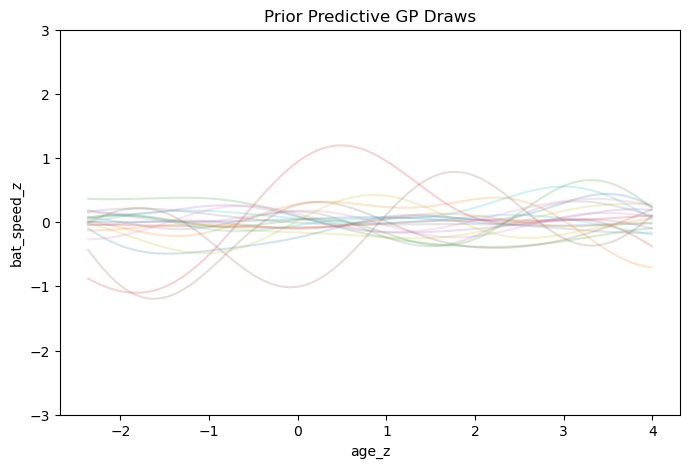

In [70]:
# prior predictve checks
samps = 20
with model:
    prior_samples = pm.sample_prior_predictive(samples=samps, var_names=["eta", "ls", "f"], random_seed=RANDOM_SEED)

# gp draws directly from HSGP
gp_draws = prior_samples.prior["f"].values.reshape(-1, len(age_z))
plt.figure(figsize=(8, 5))
for draw in gp_draws:
    sort_idx = np.argsort(age_z)
    plt.plot(age_z[sort_idx], draw[sort_idx], alpha=0.2)
plt.ylim(-3, 3)
plt.xlabel("age_z")
plt.ylabel("bat_speed_z")
plt.title("Prior Predictive GP Draws")

In [71]:
# sample
trace = sample(model, draws = 2000, tune = 2000, target_accept = 0.95,  path='gp_constant.nc')

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

There were 15 divergences after tuning. Increase `target_accept` or reparameterize.


In [72]:
az.summary(trace, var_names=['eta', 'ls','mu_pop', 'sigma_pop'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
eta,0.809,0.256,0.377,1.279,0.007,0.004,1410.0,2969.0,1.0
ls,0.717,0.284,0.256,1.248,0.006,0.004,2628.0,3253.0,1.0
mu_pop,-0.308,0.120,-0.505,-0.068,0.004,0.002,1175.0,2202.0,1.0
sigma_pop,1.003,0.022,0.961,1.042,0.000,0.000,2533.0,5290.0,1.0


In [73]:
trace_df = az.summary(trace, hdi_prob=0.95)
trace_df.loc[trace_df['r_hat']>1.01]

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat


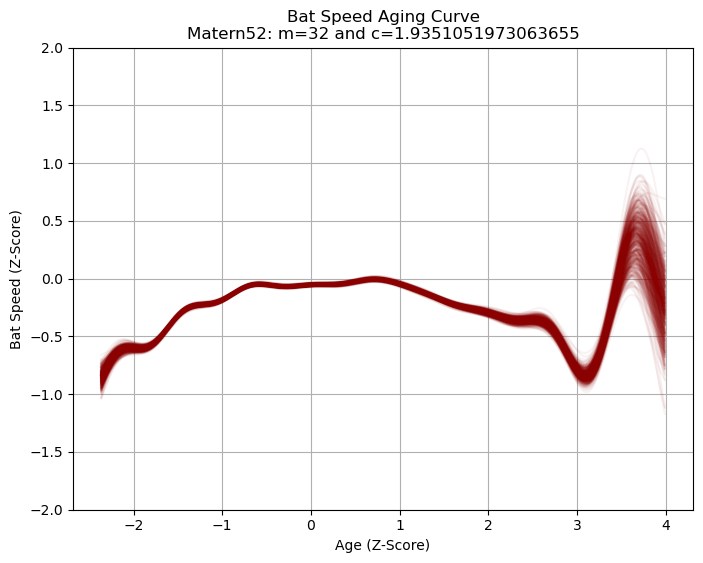

In [68]:
# plot of aging curve
f_draws = trace.posterior["f"].values
mu_pop_draws = trace.posterior["mu_pop"].values
f = f_draws.reshape(-1, f_draws.shape[-1])
mu_pop = mu_pop_draws.reshape(-1, 1)

curves = mu_pop + f
sort_idx = np.argsort(age_z)
age_sorted = age_z[sort_idx]
curves_sorted = curves[:, sort_idx]

fig, ax = plt.subplots(figsize=(8, 6))
rng = np.random.default_rng(RANDOM_SEED)
subset_indices = rng.choice(curves_sorted.shape[0], size=500, replace=False)
for idx in subset_indices:
    ax.plot(age_sorted, curves_sorted[idx, :], color="darkred", alpha=0.05)

ax.set_title(f"""Bat Speed Aging Curve\nMatern52: m={m_init} and c={c_init}""")
ax.set_xlabel("Age (Z-Score)")
ax.set_ylabel("Bat Speed (Z-Score)")
ax.set_ylim(-2, 2)
ax.grid(True)

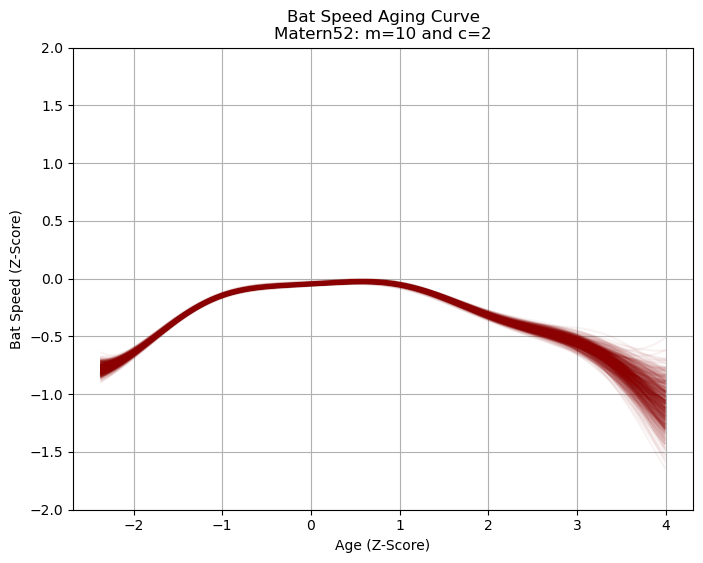

In [74]:
# plot of aging curve
f_draws = trace.posterior["f"].values
mu_pop_draws = trace.posterior["mu_pop"].values
f = f_draws.reshape(-1, f_draws.shape[-1])
mu_pop = mu_pop_draws.reshape(-1, 1)

curves = mu_pop + f
sort_idx = np.argsort(age_z)
age_sorted = age_z[sort_idx]
curves_sorted = curves[:, sort_idx]

fig, ax = plt.subplots(figsize=(8, 6))
rng = np.random.default_rng(RANDOM_SEED)
subset_indices = rng.choice(curves_sorted.shape[0], size=500, replace=False)
for idx in subset_indices:
    ax.plot(age_sorted, curves_sorted[idx, :], color="darkred", alpha=0.05)

ax.set_title(f"""Bat Speed Aging Curve\nMatern52: m=10 and c=2""")
ax.set_xlabel("Age (Z-Score)")
ax.set_ylabel("Bat Speed (Z-Score)")
ax.set_ylim(-2, 2)
ax.grid(True)

In [ ]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list
}

# matern52 with Student T
# pymc model
with pm.Model(coords=coords) as model:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    age_data = pm.Data('age_data', age_z.reshape(-1,1))
    sigma_data = pm.Data('sigma_data', bat_speed_sigma)

    # hyper priors for players
    mu_pop = pm.Normal("mu_pop", mu=0, sigma=1.0)
    sigma_pop = pm.Exponential("sigma_pop", 1.0)
    mu_player = pm.ZeroSumNormal("mu_player", sigma=sigma_pop, dims=("player",))

    # mean priors
    mean = pm.gp.mean.Zero()
    # covariance priors
    eta = pm.HalfNormal("eta", sigma=0.5)
    ls = pm.InverseGamma("ls", alpha=3.0, beta=2.0)
    cov_func = eta**2 * pm.gp.cov.Matern52(input_dim=1, ls=ls)
    # HSGP
    gp = pm.gp.HSGP(m=[10], c=c_init, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp.prior("f", X=age_data)

    # expected value
    theta = mu_pop + mu_player[player_idx] + f
    nu = pm.Exponential("nu", 1.0)
    target = pm.StudentT("target", nu=nu, mu=theta, sigma=sigma_data, observed=bat_speed_z)

In [76]:
# sample
trace = sample(model, draws = 2000, tune = 2000, target_accept = 0.99,  path='gp_student.nc')

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [77]:
trace_df = az.summary(trace, hdi_prob=0.95)
trace_df.loc[trace_df['r_hat']>1.01]

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat


In [78]:
az.summary(trace, var_names=['eta', 'ls', 'nu', 'mu_pop', 'sigma_pop'], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
eta,0.459,0.175,0.184,0.810,0.003,0.002,3858.0,5719.0,1.0
ls,1.202,0.625,0.248,2.437,0.011,0.008,3891.0,4992.0,1.0
nu,1.422,0.020,1.383,1.463,0.000,0.000,16124.0,5670.0,1.0
mu_pop,-0.367,0.068,-0.499,-0.234,0.001,0.001,2986.0,4343.0,1.0
sigma_pop,0.927,0.022,0.886,0.971,0.000,0.000,5177.0,5704.0,1.0


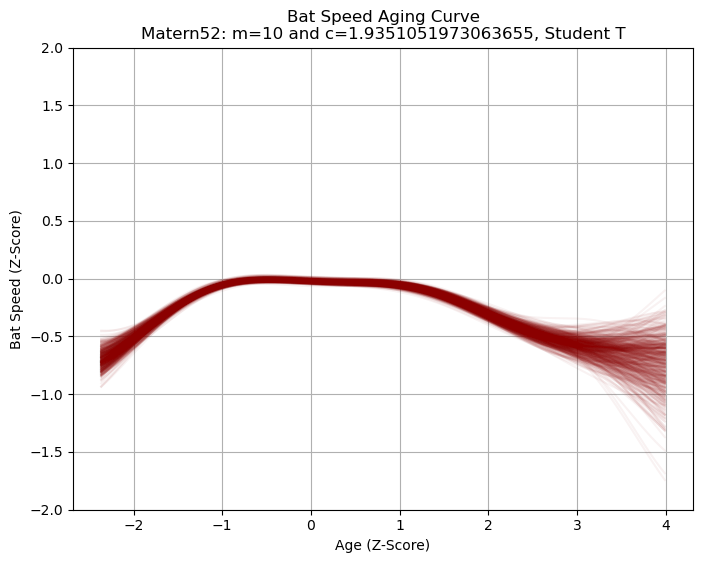

In [79]:
f_draws = trace.posterior["f"].values
mu_pop_draws = trace.posterior["mu_pop"].values
f = f_draws.reshape(-1, f_draws.shape[-1])
mu_pop = mu_pop_draws.reshape(-1, 1)

curves = f + mu_pop
sort_idx = np.argsort(age_z)
age_sorted = age_z[sort_idx]
curves_sorted = curves[:, sort_idx]

fig, ax = plt.subplots(figsize=(8, 6))
rng = np.random.default_rng(RANDOM_SEED)
subset_indices = rng.choice(curves_sorted.shape[0], size=500, replace=False)
for idx in subset_indices:
    ax.plot(age_sorted, curves_sorted[idx, :], color="darkred", alpha=0.05)

ax.set_title(f"""Bat Speed Aging Curve\nMatern52: m=10 and c={c_init}, Student T""")
ax.set_xlabel("Age (Z-Score)")
ax.set_ylabel("Bat Speed (Z-Score)")
ax.set_ylim(-2, 2)
ax.grid(True)

# better, smoother aging curve due to lengthscale

In [ ]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list
}

# matern52 with Student T
# pymc model
with pm.Model(coords=coords) as model:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    age_data = pm.Data('age_data', age_z.reshape(-1,1))
    sigma_data = pm.Data('sigma_data', bat_speed_sigma)

    # hyper priors for players
    mu_pop = pm.Normal("mu_pop", mu=0, sigma=1.0)
    sigma_pop = pm.Exponential("sigma_pop", 1.0)
    mu_player = pm.ZeroSumNormal("mu_player", sigma=sigma_pop, dims=("player",))

    # mean priors
    mean = pm.gp.mean.Zero()
    # covariance priors
    eta = pm.HalfNormal("eta", sigma=0.5)
    ls = pm.InverseGamma("ls", alpha=3.0, beta=1.5)
    cov_func = eta**2 * pm.gp.cov.Matern52(input_dim=1, ls=ls)
    # HSGP
    gp = pm.gp.HSGP(m=[6], c=2.25, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp.prior("f", X=age_data)

    # expected value
    theta = mu_pop + mu_player[player_idx] + f
    nu = pm.Exponential("nu", 1.0)
    target = pm.StudentT("target", nu=nu, mu=theta, sigma=sigma_data, observed=bat_speed_z)

In [86]:
# sample
trace = sample(model, draws = 2000, tune = 2000, target_accept = 0.99,  path='gp_student.nc')

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [87]:
trace_df = az.summary(trace, hdi_prob=0.95)
trace_df.loc[trace_df['r_hat']>1.01]

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat


In [88]:
az.summary(trace, var_names=['eta','ls','mu_pop', 'sigma_pop'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
eta,0.980,0.245,0.578,1.457,0.005,0.003,2456.0,3626.0,1.0
ls,0.912,0.475,0.241,1.789,0.009,0.010,3552.0,3275.0,1.0
mu_pop,-0.646,0.092,-0.817,-0.469,0.003,0.002,1047.0,1943.0,1.0
sigma_pop,0.927,0.021,0.889,0.968,0.000,0.000,2938.0,5820.0,1.0


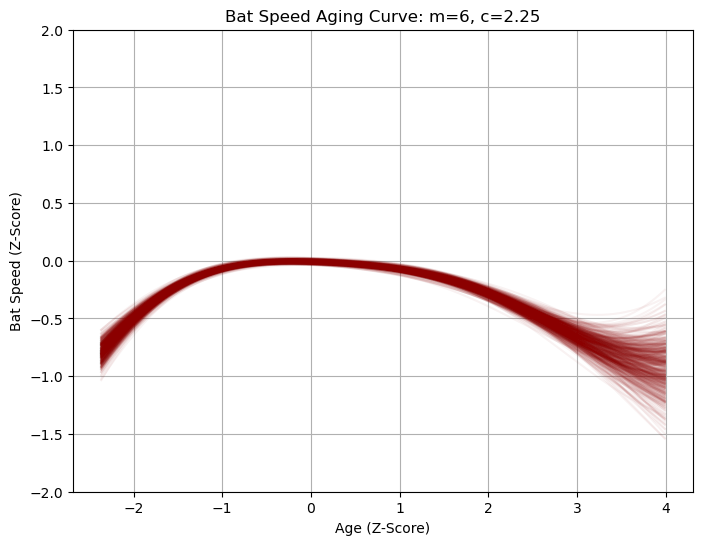

In [89]:
f_draws = trace.posterior["f"].values
mu_pop_draws = trace.posterior["mu_pop"].values
f = f_draws.reshape(-1, f_draws.shape[-1])
mu_pop = mu_pop_draws.reshape(-1, 1)

curves = f + mu_pop
sort_idx = np.argsort(age_z)
age_sorted = age_z[sort_idx]
curves_sorted = curves[:, sort_idx]

fig, ax = plt.subplots(figsize=(8, 6))
rng = np.random.default_rng(RANDOM_SEED)
subset_indices = rng.choice(curves_sorted.shape[0], size=500, replace=False)
for idx in subset_indices:
    ax.plot(age_sorted, curves_sorted[idx, :], color="darkred", alpha=0.05)

ax.set_title("Bat Speed Aging Curve: m=6, c=2.25")
ax.set_xlabel("Age (Z-Score)")
ax.set_ylabel("Bat Speed (Z-Score)")
ax.set_ylim(-2, 2)
ax.grid(True)

In [237]:
# extend the model with other random effects
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list,
    "position": position_list
}

with pm.Model(coords=coords) as model:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    position_idx = pm.Data("position_idx", position_idx_vals, dims=("player",))
    age_data = pm.Data('age_data', age_z.reshape(-1,1))
    sigma_data = pm.Data('sigma_data', bat_speed_sigma, dims=("observation_id",))

    mu = pm.Normal('mu', mu=0.0, sigma=1.0)
    # position prior
    sigma_position = pm.Exponential("sigma_position", 1.0)
    position_offset = pm.ZeroSumNormal(
        "position_offset",
        sigma = sigma_position,
        dims  = "position"
    )
    
    # player
    sigma_player = pm.Exponential("sigma_player", 1.0)
    player_z     = pm.ZeroSumNormal("player_z", sigma=1.0, dims="player")
    player_offset = pm.Deterministic(
        "player_offset",
        position_offset[position_idx] + player_z * sigma_player,
        dims = "player"
    )

    # GP set up
    # mean priors
    mean = pm.gp.mean.Zero()
    # covariance priors
    eta = pm.HalfNormal("eta", sigma=0.5)
    ls = pm.InverseGamma("ls", alpha=4.0, beta=3.0)
    cov_func = eta**2 * pm.gp.cov.Matern52(input_dim=1, ls=ls)
    # HSGP
    gp = pm.gp.HSGP(m=[10], c=2, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp.prior("f", X=age_data)

    # expected value
    theta = mu + player_offset[player_idx] + f
    target = pm.Normal("target", mu=theta, sigma=sigma_data, observed=bat_speed_z, dims=("observation_id",))

In [227]:
df[['player_full_id','model_bat_speed_z','player_idx','position_idx','age_z']].tail(8)

,player_full_id,model_bat_speed_z,player_idx,position_idx,age_z
15195,Ben Williamson (810938),-0.526678,1187,2,-1.133925
15196,Ben Williamson (810938),-0.474437,1187,2,-1.111286
15197,Ben Williamson (810938),-0.288886,1187,2,-1.087892
15198,Ben Williamson (810938),-0.758006,1187,2,-1.065253
15199,Ben Williamson (810938),-0.203144,1187,2,-0.858485
15200,Ben Williamson (810938),-0.328240,1187,2,-0.835846
15201,Ryan Waldschmidt (814439),0.600281,1188,6,-1.364841
15202,Sung-Mun Song (823550),0.073803,1189,2,0.317982


In [ ]:
# simulate it
# make it simple original idea

In [238]:
# sample
trace = sample(model, draws = 1000, tune = 1000, target_accept = 0.99,  path='gp_full.nc')

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [239]:
az.summary(trace, var_names=['position_offset'], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
position_offset[1B],0.327,0.093,0.187,0.467,0.044,0.016,5.0,20.0,2.34
position_offset[C],-0.137,0.079,-0.254,0.049,0.036,0.023,5.0,19.0,2.51
position_offset[2B],-0.495,0.077,-0.688,-0.387,0.033,0.020,6.0,17.0,1.86
position_offset[DH],0.647,0.105,0.433,0.811,0.048,0.024,6.0,16.0,1.93
position_offset[LF],0.015,0.078,-0.193,0.125,0.036,0.022,5.0,13.0,2.56
position_offset[SS],-0.396,0.060,-0.529,-0.297,0.024,0.010,7.0,20.0,1.51
position_offset[CF],0.000,0.042,-0.076,0.071,0.016,0.005,7.0,26.0,1.54
position_offset[3B],-0.109,0.068,-0.223,0.009,0.027,0.009,7.0,22.0,1.60
position_offset[RF],0.447,0.063,0.367,0.566,0.029,0.013,6.0,45.0,1.71
position_offset[OF],-0.301,0.110,-0.508,-0.076,0.023,0.011,22.0,41.0,1.16


array([[<Axes: title={'center': 'position_effect'}>,
        <Axes: title={'center': 'position_effect'}>],
       [<Axes: title={'center': 'sigma_position'}>,
        <Axes: title={'center': 'sigma_position'}>]], dtype=object)

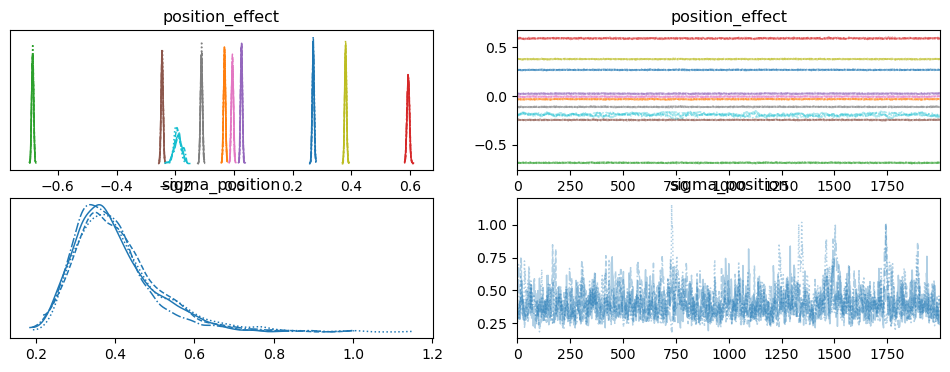

In [207]:
az.plot_trace(trace, var_names=['position_effect','sigma_position'])

In [ ]:
# STOP HERE

In [ ]:
# pymc model
with pm.Model() as model:
    # data
    age_stack_data = pm.Data('age_stack_data', age_stack)
    sigma_data = pm.Data('sigma_data', train_bat_speed_std_z)

    # priors
    b = pm.Normal("b", mu=-0.125, sigma=0.05)
    a = pm.Normal("a", mu=-0.02, sigma=0.01)
    coefs = pt.stack([a, b])[:, None]
    mean = pm.gp.mean.Linear(coeffs=coefs, intercept=0.0)

    # GP priors
    eta =pm.HalfNormal("eta", sigma=1.0)
    ls = pm.Gamma("ls", alpha=5.0, beta=1.0)
    cov_func = eta**2 * pm.gp.cov.ExpQuad(input_dim=2, ls=ls, active_dims=[1])

    # expected value
    theta = age_stack_data

    # likelihood, need to figure out m and L a bit more
    gp = pm.gp.HSGP(m=[30], L=[10.0], mean_func=mean, cov_func=cov_func)
    f = gp.prior("f", X=theta)
    target = pm.Normal("target", mu=pt.flatten(f), sigma=sigma_data, observed=train_bat_speed_z)

Text(0.5, 1.0, 'Prior Predictive GP Draws')

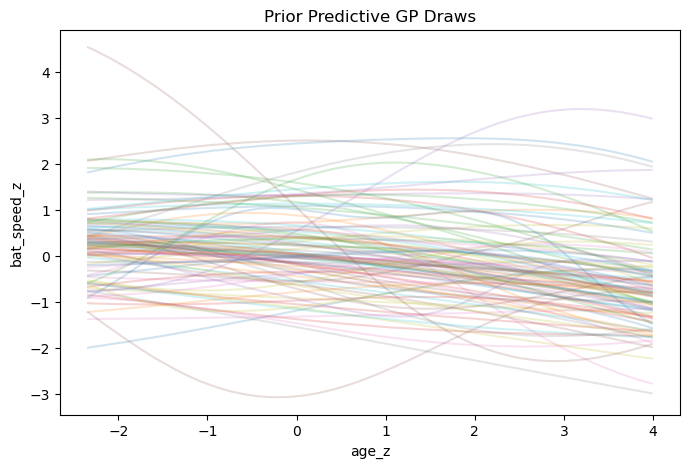

In [68]:
# by hand
gp_draws = []
a_draws = prior_samples.prior["a"].values.flatten()
b_draws = prior_samples.prior["b"].values.flatten()

eta_draws = prior_samples.prior["eta"].values.flatten()
ls_draws = prior_samples.prior["ls"].values.flatten()

age_list = np.linspace(train_age.min(), train_age.max(), 100)
age_grid = np.column_stack([age_list**2, age_list])

for a_i, b_i, eta_i, ls_i in zip(
    a_draws,
    b_draws,
    eta_draws,
    ls_draws
):
    # mean
    m = a_i * age_grid[:, 0] + b_i * age_grid[:, 1] + 0

    # covar
    K = eta_i**2 * np.exp(-0.5 * (age_grid[:, 1][:, None] - age_grid[:, 1][None, :])**2 / ls_i**2)
    K += 1e-6 * np.eye(len(age_grid))
    f = np.random.multivariate_normal(m, K)
    gp_draws.append(f)

gp_draws = np.asarray(gp_draws)

# plot gp draws by hand
plt.figure(figsize=(8, 5))
for draw in gp_draws:
    plt.plot(age_list, draw, alpha=0.2)

plt.xlabel("age_z")
plt.ylabel("bat_speed_z")
plt.title("Prior Predictive GP Draws")

Text(0.5, 1.0, 'Prior Predictive GP Draws')

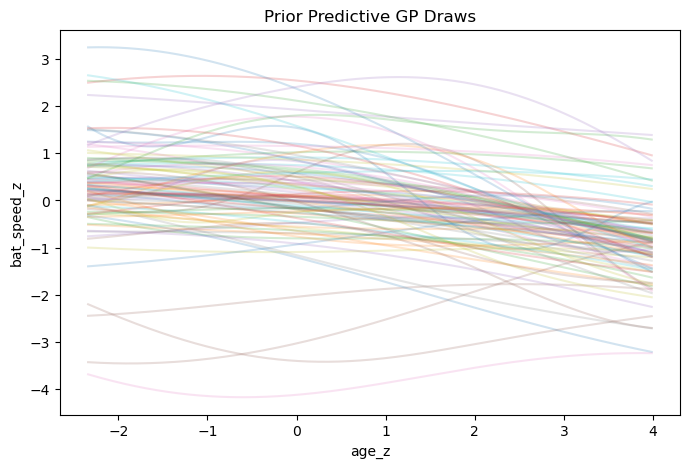

In [69]:
# gp draws directly from HSGP
gp_draws = prior_samples.prior["f"].values.reshape(-1, len(train_age))
plt.figure(figsize=(8, 5))
for draw in gp_draws:
    sort_idx = np.argsort(train_age)
    plt.plot(train_age[sort_idx], draw[sort_idx], alpha=0.2)
plt.xlabel("age_z")
plt.ylabel("bat_speed_z")
plt.title("Prior Predictive GP Draws")

Text(0.5, 1.0, 'Prior Predictive Quad Curves')

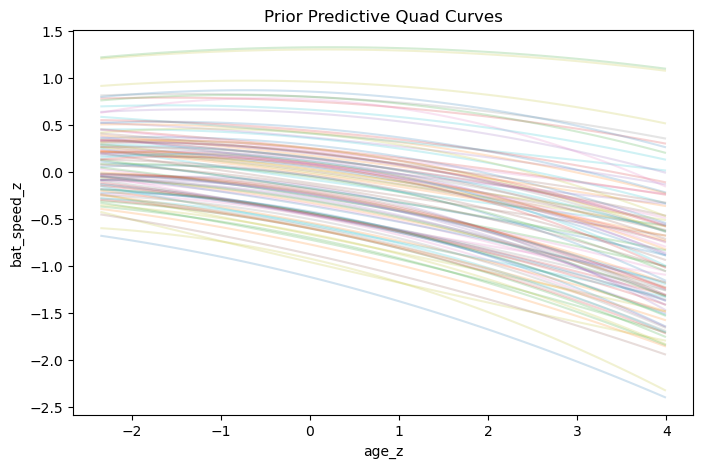

In [70]:
# plot of jsut the coefs
plt.figure(figsize=(8, 5))
for a_i, b_i, c_i in zip(a_draws, b_draws, c_draws):
    m = a_i * age_list**2 + b_i * age_list + c_i
    plt.plot(age_list, m, alpha=0.2)
plt.xlabel("age_z")
plt.ylabel("bat_speed_z")
plt.title("Prior Predictive Quad Curves")